In [15]:
import sys

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import importlib

In [76]:
MODULES_PATH = Path("../modules").resolve()

if str(MODULES_PATH) not in sys.path:
    sys.path.insert(0, str(MODULES_PATH))

In [78]:
metrics = dev.load_metrics()

In [79]:
metrics.keys()

dict_keys(['epi_001', 'epi_002', 'epi_003', 'epi_004', 'epi_005', 'epi_006', 'epi_007', 'epi_008', 'epi_009', 'epi_010', 'epi_011'])

In [80]:
entity_df = dev.build_long_df(metrics, category="entity")

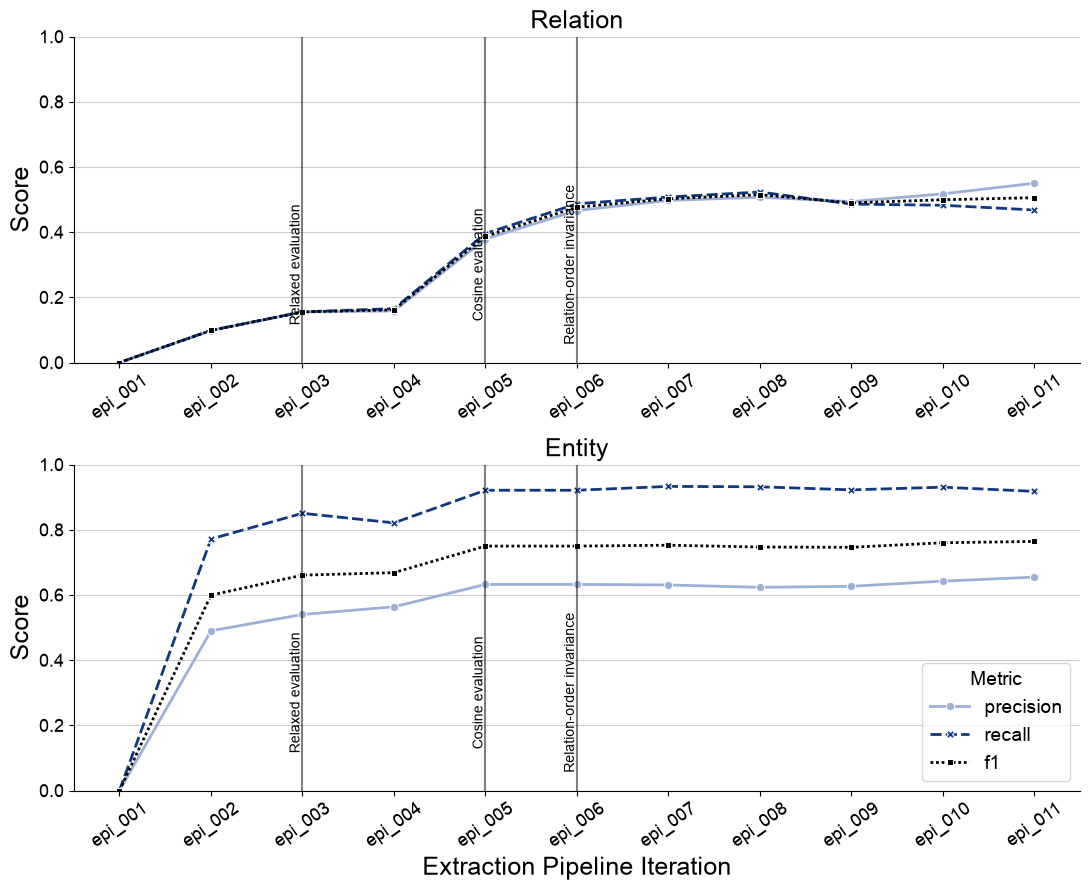

In [101]:
import dev_analysis
importlib.reload(dev)
import dev_analysis as dev

dev.plot_performance_line(metrics, save=True)

In [7]:
wide_relation_df = relation_df.pivot(
    index=['epi_id', 'match_type'],
    columns='metric',
    values='value'
).reset_index()

wide_relation_df.columns.name = None

sorted_wide_relation_df = wide_relation_df.sort_values(by="f1",axis=0, ascending=False).iloc[:3]

sorted_wide_relation_df

,epi_id,match_type,f1,precision,recall
7,epi_008,cosine,0.5149,0.5070,0.5230
10,epi_011,cosine,0.5056,0.5499,0.4679
6,epi_007,cosine,0.5025,0.4973,0.5077


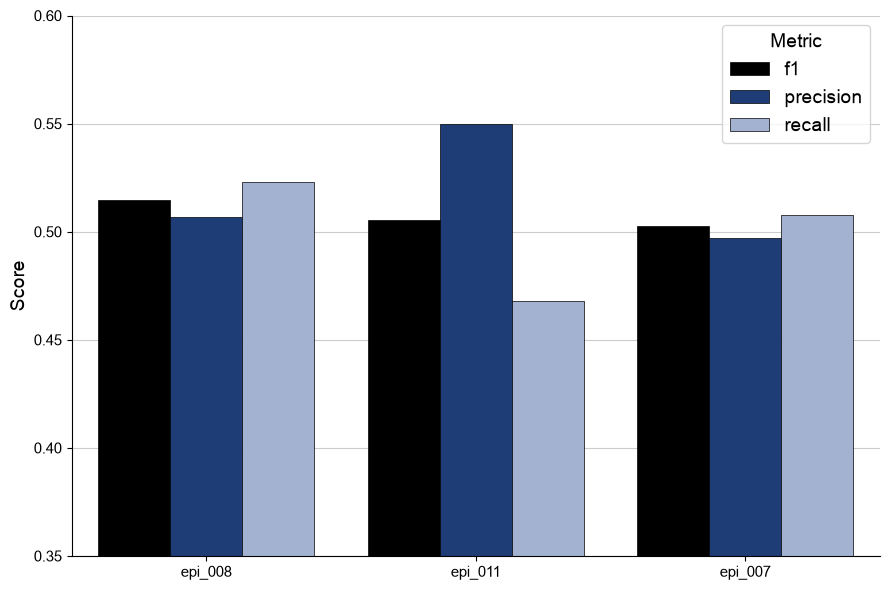

In [8]:
melted_relation_df = sorted_wide_relation_df.drop("match_type", axis=1).melt(id_vars="epi_id", var_name="metric")

fig, ax = plt.subplots(figsize=(9,6))

ax = sns.barplot(
    data=melted_relation_df,
    x="epi_id", y="value",
    hue="metric",
    edgecolor="black",
    linewidth=0.5,
    palette=["#000000", "#103783", "#9bafd9"]
)

ax.set_ylim((0.35, 0.6))
ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=14)
ax.tick_params(labelsize=11)

ax.set_axisbelow(True)
ax.grid(axis="y", color="black", alpha=0.2)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.legend(title="Metric", title_fontsize=14, fontsize=14)

fig.tight_layout()